## DSA5105 Project - Astronomical Stellar Classification

#### Name: Wong Zi Xin, Avellin
#### Student ID: A0225646B

### Content
The data consists of 100,000 observations of space taken by the SDSS (Sloan Digital Sky Survey). Every observation is described by 17 feature columns and 1 class column which identifies it to be either a star, galaxy or quasar.

- obj_ID = Object Identifier, the unique value that identifies the object in the image catalog used by the CAS
- alpha = Right Ascension angle (at J2000 epoch)
- delta = Declination angle (at J2000 epoch)
- u = Ultraviolet filter in the photometric system
- g = Green filter in the photometric system
- r = Red filter in the photometric system
- i = Near Infrared filter in the photometric system
- z = Infrared filter in the photometric system
- run_ID = Run Number used to identify the specific scan
- rereun_ID = Rerun Number to specify how the image was processed
- cam_col = Camera column to identify the scanline within the run
- field_ID = Field number to identify each field
- spec_obj_ID = Unique ID used for optical spectroscopic objects (this means that 2 different observations with the same spec_obj_ID must share the output class)
- class = object class (galaxy, star or quasar object)
- redshift = redshift value based on the increase in wavelength
- plate = plate ID, identifies each plate in SDSS
- MJD = Modified Julian Date, used to indicate when a given piece of SDSS data was taken
- fiber_ID = fiber ID that identifies the fiber that pointed the light at the focal plane in each observation

In [88]:
!pip install umap-learn

In [2]:
import joblib
import umap
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import make_scorer, precision_score, recall_score, accuracy_score, silhouette_score, adjusted_rand_score

In [3]:
# Read the dataset
stars = pd.read_csv("./stellar-classification-dataset/star_classification.csv")

stars.head()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,class,redshift,plate,MJD,fiber_ID
0,1.237661e+18,135.689107,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.543777e+18,GALAXY,0.634794,5812,56354,171
1,1.237665e+18,144.826101,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.176014e+19,GALAXY,0.779136,10445,58158,427
2,1.237661e+18,142.188790,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.152200e+18,GALAXY,0.644195,4576,55592,299
3,1.237663e+18,338.741038,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030107e+19,GALAXY,0.932346,9149,58039,775
4,1.237680e+18,345.282593,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,8102,301,3,137,6.891865e+18,GALAXY,0.116123,6121,56187,842


### Data Exploration

In [3]:
stars.isnull().sum()

obj_ID         0
alpha          0
delta          0
u              0
g              0
r              0
i              0
z              0
run_ID         0
rerun_ID       0
cam_col        0
field_ID       0
spec_obj_ID    0
class          0
redshift       0
plate          0
MJD            0
fiber_ID       0
dtype: int64

We can see that there are no NULL fields in the dataset, which is great and makes it easier to work with

In [4]:
stars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   obj_ID       100000 non-null  float64
 1   alpha        100000 non-null  float64
 2   delta        100000 non-null  float64
 3   u            100000 non-null  float64
 4   g            100000 non-null  float64
 5   r            100000 non-null  float64
 6   i            100000 non-null  float64
 7   z            100000 non-null  float64
 8   run_ID       100000 non-null  int64  
 9   rerun_ID     100000 non-null  int64  
 10  cam_col      100000 non-null  int64  
 11  field_ID     100000 non-null  int64  
 12  spec_obj_ID  100000 non-null  float64
 13  class        100000 non-null  object 
 14  redshift     100000 non-null  float64
 15  plate        100000 non-null  int64  
 16  MJD          100000 non-null  int64  
 17  fiber_ID     100000 non-null  int64  
dtypes: float64(10), int64(7),

Since the target variable, i.e., the 'class' column is of non-numeric type, we'll have to perform encoding.

In [5]:
stars.describe()

,obj_ID,alpha,delta,u,g,r,i,z,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,redshift,plate,MJD,fiber_ID
count,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.237665e+18,177.629117,24.135305,21.980468,20.531387,19.645762,19.084854,18.668810,4481.366060,301.0,3.511610,186.130520,5.783882e+18,0.576661,5137.009660,55588.647500,449.312740
std,8.438560e+12,96.502241,19.644665,31.769291,31.750292,1.854760,1.757895,31.728152,1964.764593,0.0,1.586912,149.011073,3.324016e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.237646e+18,0.005528,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,109.000000,301.0,1.000000,11.000000,2.995191e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.237659e+18,127.518222,5.146771,20.352353,18.965230,18.135828,17.732285,17.460677,3187.000000,301.0,2.000000,82.000000,2.844138e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.237663e+18,180.900700,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,4188.000000,301.0,4.000000,146.000000,5.614883e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.237668e+18,233.895005,39.901550,23.687440,22.123767,21.044785,20.396495,19.921120,5326.000000,301.0,5.000000,241.000000,8.332144e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.237681e+18,359.999810,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,8162.000000,301.0,6.000000,989.000000,1.412694e+19,7.011245,12547.000000,58932.000000,1000.000000


In [6]:
stars['class'].unique()

array(['GALAXY', 'QSO', 'STAR'], dtype=object)

In [7]:
stars['class'].value_counts()

class
GALAXY    59445
STAR      21594
QSO       18961
Name: count, dtype: int64

Since there is a class imbalance in the dataset, we'll address this issue through resampling techniques.

### Feature Extraction and Model Preparation

To predict the class of the astronomical object (galaxy, star, quasar), it is important to choose features that contain information about the object's physical properties, appearance or spectral characteristics, and avoid features that are more related to the observation process itself. In this case, features such as run_ID, rereun_ID, cam_col, field_ID, plate, fiber_ID are related to the observation process and are hence unlikely to contain meaningful information for classification.

The most important features are: 
- u, g, r, i, z: These photometric measurements represent the brightness of an object in different wavelength bands.
- redshift: Extremely useful for distinguishing between galaxies, stars, and quasars.
Stars usually have negligible redshifts because they are within the Milky Way.
Quasars, being highly distant objects, have high redshifts.
Galaxies have redshifts that depend on their distance and motion.
- alpha (RA) and delta (Dec): These may not directly determine the class, but they can add context in certain cases (e.g., if the region of the sky is known to host specific types of objects).
- MJD (Modified Julian Date): This could be indirectly helpful if the object's brightness varies over time (e.g., variable stars or quasars).

In [29]:
X = stars[['u', 'g', 'r', 'i', 'z', 'redshift', 'alpha', 'delta', 'MJD']]
X

,u,g,r,i,z,redshift,alpha,delta,MJD
0,23.87882,22.27530,20.39501,19.16573,18.79371,0.634794,135.689107,32.494632,56354
1,24.77759,22.83188,22.58444,21.16812,21.61427,0.779136,144.826101,31.274185,58158
2,25.26307,22.66389,20.60976,19.34857,18.94827,0.644195,142.188790,35.582444,55592
3,22.13682,23.77656,21.61162,20.50454,19.25010,0.932346,338.741038,-0.402828,58039
4,19.43718,17.58028,16.49747,15.97711,15.54461,0.116123,345.282593,21.183866,56187
...,...,...,...,...,...,...,...,...,...
99995,22.16759,22.97586,21.90404,21.30548,20.73569,0.000000,39.620709,-2.594074,57749
99996,22.69118,22.38628,20.45003,19.75759,19.41526,0.404895,29.493819,19.798874,56934
99997,21.16916,19.26997,18.20428,17.69034,17.35221,0.143366,224.587407,15.700707,54535
99998,25.35039,21.63757,19.91386,19.07254,18.62482,0.455040,212.268621,46.660365,56368


In [30]:
y = stars['class']
y

0        GALAXY
1        GALAXY
2        GALAXY
3        GALAXY
4        GALAXY
          ...  
99995    GALAXY
99996    GALAXY
99997    GALAXY
99998    GALAXY
99999    GALAXY
Name: class, Length: 100000, dtype: object

In [31]:
# Perform encoding since class is a categorical variable
le = LabelEncoder()
y = pd.Series(le.fit_transform(y))
y

0        0
1        0
2        0
3        0
4        0
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Length: 100000, dtype: int32

In [97]:
# Perform scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [33]:
# Perform resampling due to class imbalance
sm = SMOTE(random_state = 30, k_neighbors = 5)
X_res, y_res = sm.fit_resample(X_scaled, y)

In [34]:
y_res.value_counts()

0    59445
1    59445
2    59445
Name: count, dtype: int64

Now the classes have equal number of data points

### Data Visualisations

#### Position of the objects on the celestial sphere

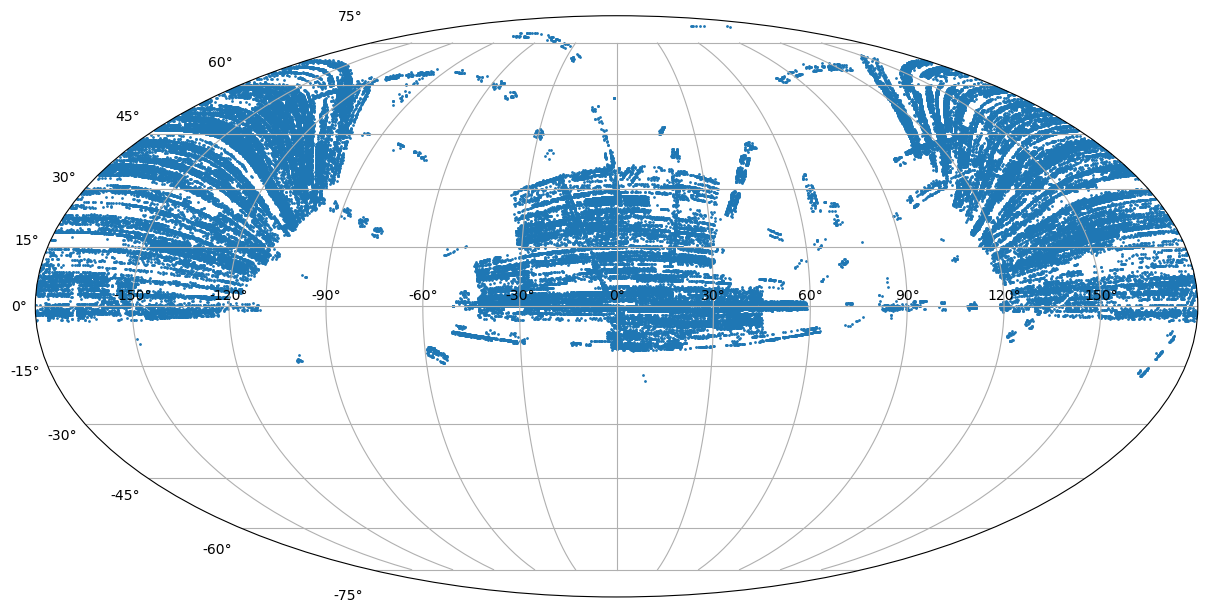

In [ ]:
from astropy.coordinates import SkyCoord
import astropy.units as u
coords = SkyCoord(ra=stars['alpha'], dec=stars['delta'], frame='icrs', unit='deg')

fig = plt.figure(figsize=(15,15))
ax = fig.add_subplot(111, projection='mollweide')
ax.scatter(coords.ra.wrap_at(180*u.degree).radian, coords.dec.radian, s=1)
ax.grid()
plt.show()

This is a Mollweide projection plot showing the spatial distribution of celestial objects in the sky. The axes represent right ascension (RA) and declination (Dec) in degrees, projected onto an oval shape to account for the spherical nature of the celestial coordinate system.

The distinct striped pattern suggests that the data was collected through a survey that scanned the sky in specific bands or strips.

Most of the data appears to be concentrated around the celestial equator (Dec = 0°) and specific RA ranges. This is typical for surveys that focus on particular regions of the sky.

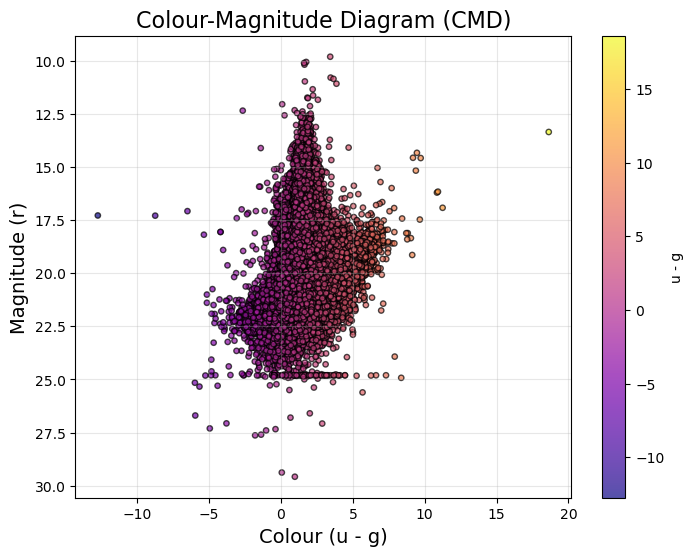

In [26]:
# Define colours
colour = stars['u'] - stars['g']
# Define magnitude
mag = stars['r']

# Create the CMD
plt.figure(figsize=(8, 6))
sc = plt.scatter(colour, mag, c=colour, cmap='plasma', alpha=0.7, edgecolor='k', s=15)
plt.colorbar(sc, label='u - g')  # Add colour bar for reference

# Formatting the plot
plt.gca().invert_yaxis()  # Invert magnitude axis (lower magnitudes are brighter)
plt.title("Colour-Magnitude Diagram (CMD)", fontsize=16)
plt.xlabel("Colour (u - g)", fontsize=14)
plt.ylabel("Magnitude (r)", fontsize=14)
plt.grid(alpha=0.3)
plt.show()

Colour Distribution (x axis: u-g): 
- The x-axis represents the difference in magnitude between the u (ultraviolet) and g (green) bands.
- Objects with smaller values of u - g (bluer/purple color, on the left) are hotter and typically younger (for stars).
- Higher values of u - g (redder/yellow color, on the right) are cooler and generally older (for stars).

Magnitude Distribution (y axis: r):
- The y-axis represents the brightness of the object in the r (red) band. Note that the magnitude axis is inverted (brighter objects have smaller magnitude values).
- Brighter objects (closer to the top) appear more isolated, while fainter objects (towards the bottom) form dense clusters.

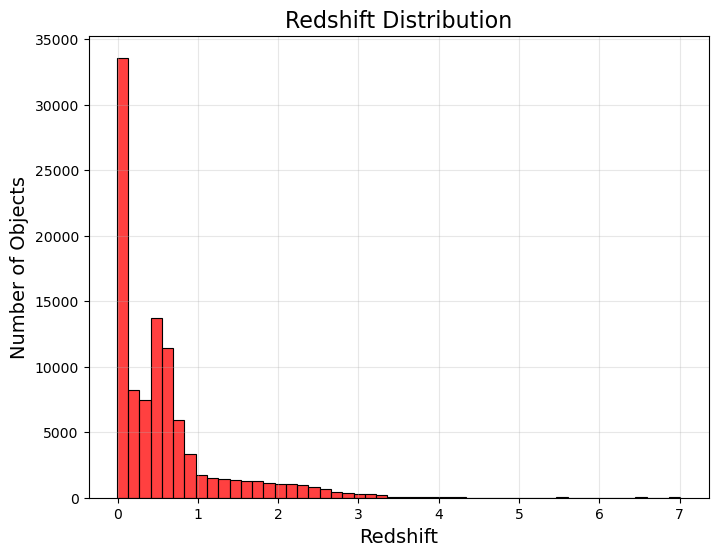

In [27]:
plt.figure(figsize=(8, 6))
sns.histplot(data=stars, x='redshift', bins=50, kde=False, color='red')

# Customize the plot
plt.title('Redshift Distribution', fontsize=16)
plt.xlabel('Redshift', fontsize=14)
plt.ylabel('Number of Objects', fontsize=14)
plt.grid(alpha=0.3)
plt.show()

Redshift measures how much the light from an object has been stretched due to the expansion of the universe.
Low redshift values correspond to nearby objects, while higher values indicate more distant, older objects that are farther back in cosmic history.

The histogram shows a sharp peak at very low redshift values (close to 0), indicating that the majority of the observed objects are relatively nearby on a cosmological scale. This suggests a dataset dominated by objects within the local universe or relatively close galaxies.

As the redshift increases, the number of objects rapidly declines, forming a long tail that extends up to around 𝑧 ≈ 7. High-redshift objects are less common, which aligns with the challenges in observing distant galaxies or quasars due to their faintness and the limitations of telescope sensitivity.

This makes sense given the class imbalance in our dataset, with the least number of objects being quasars (which generally has the highest redshift). Stars have low redshift (often near 0), forming the peak of our histogram. Galaxies generally have higher redshift than stars but lower than quasars (depending on how distant they are). In our case, moderate redshift values (0.1 to 1) likely represent galaxies at intermediate distances.

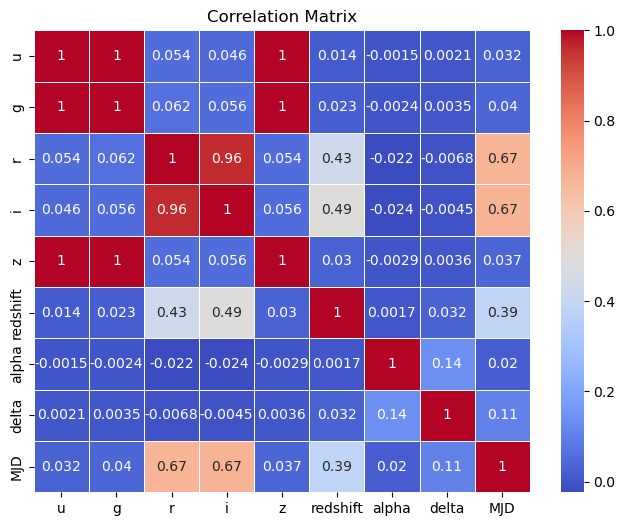

In [35]:
correlation_matrix = X.corr() # Using the original features

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Matrix")
plt.show()

### Supervised Learning

The supervised learning task involves predicting the class of the astronomical object (galaxy, star, quasar) from its physical properties and spectral characteristics. Here I will utilise 4 different models - Logistic Regression, K-Nearest Neighbours, Histogram-based Gradient Boosting Classification Tree and Random Forest. Histogram-based Gradient Boosting Classification Tree is much faster than regular Gradient Boosted Trees for large datasets (n_samples >= 10 000). For each model, I will use 3-fold cross validation across a hyperparameter grid to determine the best combination of hyperparameters based on model accuracy, before using accuracy, precision and recall to evaluate the best model on both the training and test sets.

First, I split the data based on a 80%/20% ratio into training and test sets.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

Define models for supervised learning. The max_iter parameter for logistic regression has been increased as the default value (100) was unable to lead to convergence

In [53]:
lr = LogisticRegression(max_iter=1000) 
# LR: To enable convergence
knn = KNeighborsClassifier()
gbt = HistGradientBoostingClassifier()
rf = RandomForestClassifier()

#### Hyperparameters

Define the hyperparameters to run Grid Search Cross Validation on. 

For Logistic Regression, C is the inverse of regularization strength. The smaller the value, the stronger the regularization. 

For K nearest neighbours, p=1 refers to Manhattan distance, and p=2 refers to Euclidean distance as the distance metric. 'weights'=uniform means that all points in each neighborhood are weighted equally, while 'weights'=distance means that points are weighted by the inverse of their distance, and closer neighbours of a query point will have a greater influence than neighbors which are further away.

In [ ]:
param_grid_lr = {
    'penalty': ['l2'],
    'C': [0.01, 0.1, 1, 10, 100]
}

param_grid_knn = {
    'n_neighbors': [1, 3, 5, 7, 9], 
    'weights': ['uniform', 'distance'],
    'p': [1, 2]
}

param_grid_gbt = {
    'max_iter': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2], 
    'max_depth': [3, 5, 7, None]
}

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

In [68]:
# Define custom scorers with weighted averaging for multiclass
scoring = {
    'accuracy': make_scorer(accuracy_score),  # Accuracy does not require averaging
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted')
}


grid_lr = GridSearchCV(lr, param_grid_lr, cv=3, scoring=scoring, refit='accuracy')
grid_knn = GridSearchCV(knn, param_grid_knn, cv=3, scoring=scoring, refit='accuracy')
grid_gbt = GridSearchCV(gbt, param_grid_gbt, cv=3, scoring=scoring, refit='accuracy')
grid_rf = GridSearchCV(rf, param_grid_rf, cv=3, scoring=scoring, refit='accuracy')

In [ ]:
# grid_lr.fit(X_train, y_train)
# joblib.dump(grid_lr, 'lr_grid.pkl')

['lr_grid.pkl']

In [ ]:
# grid_knn.fit(X_train, y_train)
# joblib.dump(grid_knn, 'knn_grid.pkl')

['knn_grid.pkl']

In [ ]:
# grid_gbt.fit(X_train, y_train)
# joblib.dump(grid_gbt, 'gbt_grid.pkl')

['gbt_grid.pkl']

In [ ]:
# grid_rf.fit(X_train, y_train)
# joblib.dump(grid_rf, 'rf_grid.pkl')

['rf_grid.pkl']

In [125]:
# Load the saved Grid objects
loaded_grid_lr = joblib.load('lr_grid.pkl')
loaded_grid_knn = joblib.load('knn_grid.pkl')
loaded_grid_gbt = joblib.load('gbt_grid.pkl')
loaded_grid_rf = joblib.load('rf_grid.pkl')

#### Logistic Regression

In [49]:
best_lr = loaded_grid_lr.best_estimator_
y_train_lr_pred = best_lr.predict(X_train)
y_test_lr_pred = best_lr.predict(X_test)

print("Logistic Regression Best Params:", loaded_grid_lr.best_params_)
print("Logistic Regression Train Accuracy:", loaded_grid_lr.score(X_train, y_train))
print("Logistic Regression Test Accuracy:", loaded_grid_lr.score(X_test, y_test))

print("Logistic Regression Train Precision:", precision_score(y_train, y_train_lr_pred, average='weighted'))
print("Logistic Regression Test Precision:", precision_score(y_test, y_test_lr_pred, average='weighted'))

print("Logistic Regression Train Recall:", recall_score(y_train, y_train_lr_pred, average='weighted'))
print("Logistic Regression Test Recall:", recall_score(y_test, y_test_lr_pred, average='weighted'))


Logistic Regression Best Params: {'C': 100, 'penalty': 'l2'}
Logistic Regression Train Accuracy: 0.9579302997168251
Logistic Regression Test Accuracy: 0.9589536546387417
Logistic Regression Train Precision: 0.9580549702957281
Logistic Regression Test Precision: 0.9590762888272902
Logistic Regression Train Recall: 0.9579302997168251
Logistic Regression Test Recall: 0.9589536546387417


Logistic Regression performs quite well with both training and test accuracy close to 96%, and precision and recall close to each other. This model demonstrates good generalization, as there is very little difference in performance between the training and test sets.

The high performance is reflected in both precision and recall, meaning that the model is making accurate predictions without favoring any particular class (balanced performance).

#### K-Nearest Neighbours (KNN)

In [ ]:
best_knn = loaded_grid_knn.best_estimator_
y_train_knn_pred = best_knn.predict(X_train)
y_test_knn_pred = best_knn.predict(X_test)

print("KNN Best Params:", loaded_grid_knn.best_params_)
print("KNN Train Accuracy:", loaded_grid_knn.score(X_train, y_train))
print("KNN Test Accuracy:", loaded_grid_knn.score(X_test, y_test))

print("KNN Train Precision:", precision_score(y_train, y_train_knn_pred, average='weighted'))
print("KNN Test Precision:", precision_score(y_test, y_test_knn_pred, average='weighted'))

print("KNN Train Recall:", recall_score(y_train, y_train_knn_pred, average='weighted'))
print("KNN Test Recall:", recall_score(y_test, y_test_knn_pred, average='weighted'))

KNN Best Params: {'n_neighbors': 1, 'p': 1, 'weights': 'uniform'}
KNN Train Accuracy: 1.0
KNN Test Accuracy: 0.9747105167241428
KNN Train Precision: 1.0
KNN Test Precision: 0.9747846360204143
KNN Train Recall: 1.0
KNN Test Recall: 0.9747105167241428


The KNN model performs perfectly on the training set (accuracy, precision, and recall are all 1.0). However, the test set shows a slight drop in performance, indicating potential overfitting. Overfitting is common when using very small values for hyperparameters like n_neighbors = 1 and p = 1 (Manhattan distance), which can memorize training data rather than generalizing well.

The test precision and recall are still high, suggesting that the model still generalizes quite well.

#### Random Forest

In [ ]:
best_rf = loaded_grid_rf.best_estimator_
y_train_rf_pred = best_rf.predict(X_train)
y_test_rf_pred = best_rf.predict(X_test)

print("Random Forest Best Params:", loaded_grid_rf.best_params_)
print("Random Forest Train Accuracy:", loaded_grid_rf.score(X_train, y_train))
print("Random Forest Test Accuracy:", loaded_grid_rf.score(X_test, y_test))

print("Random Forest Train Precision:", precision_score(y_train, y_train_rf_pred, average='weighted'))
print("Random Forest Test Precision:", precision_score(y_test, y_test_rf_pred, average='weighted'))

print("Random Forest Train Recall:", recall_score(y_train, y_train_rf_pred, average='weighted'))
print("Random Forest Test Recall:", recall_score(y_test, y_test_rf_pred, average='weighted'))

Random Forest Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Random Forest Train Accuracy: 1.0
Random Forest Test Accuracy: 0.9832618386744049
Random Forest Train Precision: 1.0
Random Forest Test Precision: 0.9832941870984767
Random Forest Train Recall: 1.0
Random Forest Test Recall: 0.9832618386744049


Random Forest shows a very strong performance with perfect accuracy, precision, and recall on the training set. Like KNN, this suggests the model is potentially overfitting. However, it still performs very well on the test set, with only a slight drop in accuracy, precision and recall.

The model generalizes well to the test data, as evidenced by the minimal difference between training and test performance. This is typical for Random Forests, which tend to handle overfitting better through ensemble methods and multiple decision trees.

#### Histogram Based Gradient Boosted Trees

In [ ]:
best_gbt = loaded_grid_gbt.best_estimator_
y_train_gbt_pred = best_gbt.predict(X_train)
y_test_gbt_pred = best_gbt.predict(X_test)

print("Histogram Based Gradient Boosted Trees Best Params:", loaded_grid_gbt.best_params_)
print("Histogram Based Gradient Boosted Trees Train Accuracy:", loaded_grid_gbt.score(X_train, y_train))
print("Histogram Based Gradient Boosted Trees Test Accuracy:", loaded_grid_gbt.score(X_test, y_test))

print("Histogram Based Gradient Boosted Tree Train Precision:", precision_score(y_train, y_train_gbt_pred, average='weighted'))
print("Histogram Based Gradient Boosted Tree Test Precision:", precision_score(y_test, y_test_gbt_pred, average='weighted'))

print("Histogram Based Gradient Boosted Tree Train Recall:", recall_score(y_train, y_train_gbt_pred, average='weighted'))
print("Histogram Based Gradient Boosted Tree Test Recall:", recall_score(y_test, y_test_gbt_pred, average='weighted'))

Histogram Based Gradient Boosted Trees Best Params: {'learning_rate': 0.1, 'max_depth': None, 'max_iter': 300}
Histogram Based Gradient Boosted Trees Train Accuracy: 0.9921986710404576
Histogram Based Gradient Boosted Trees Test Accuracy: 0.9803459780749713
Histogram Based Gradient Boosted Tree Train Precision: 0.9922170003290643
Histogram Based Gradient Boosted Tree Test Precision: 0.980425570692886
Histogram Based Gradient Boosted Tree Train Recall: 0.9921986710404576
Histogram Based Gradient Boosted Tree Test Recall: 0.9803459780749713


Histogram-Based Gradient Boosted Trees show an excellent performance with high accuracy, precision, and recall on both training and test sets. The slight drop from training to test set performance (about 1-2%) is expected due to the complexity of gradient boosting, but overall, it shows strong generalization.
The model outperforms KNN and Logistic Regression in terms of test accuracy and precision/recall, but not quite as well as Random Forest on the test set.

#### Summary and Conclusion

From our results, we can see that all 4 models performed very well on both the training and test sets, with accuracy, precision and recall all above 95%. Even the worst performing model, logistic regression, achieved an accuracy, precision and recall of close to 96% on both the training and test sets. 

On the test set, the best performing models based on accuracy are Random Forest (98.3%) and Histogram Based Gradient Boosted Trees (98.0%). 

Overall, Random Forest and Gradient Boosted Trees are likely the top contenders for this dataset due to their ability to handle large, complex datasets with high generalization.
Logistic Regression can still be a good option where a linear decision boundary is sufficient.
KNN, with its slight overfitting issues in this case, may not be the best choice unless the hyperparameters are further tuned. 

### Unsupervised Learning

The unsupervised learning task is to perform clustering on the dataset and compare the performance between the different methods. In particular, I will be using k-means clustering, Gaussian Mixture Models and DBSCAN (Density-Based Spatial Clustering of Applications with Noise).

#### K-Means

To determine the ideal number of clusters for k-means, I will be using the elbow method, which plots the Within-Cluster Sum of Squares (WCSS), also known as inertia, for a range of k values. As k increases, WCSS decreases as clusters become more specific. The "elbow" in the plot, which is where the rate of decrease in WCSS slows down, is considered the optimal number of clusters, as adding more clusters after that does not improve the model significantly. 

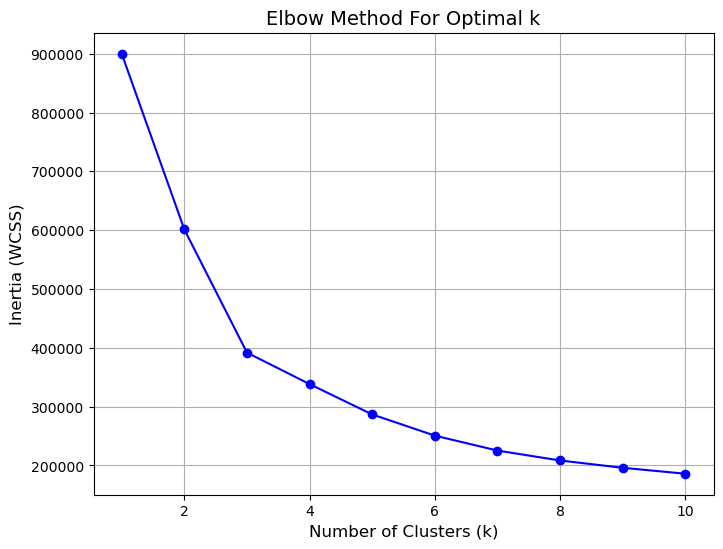

In [ ]:
inertia = []

# Run k-Means for a range of k
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)  

# Plot the Elbow Method graph
plt.figure(figsize=(8, 6))
plt.plot(range(1, 11), inertia, marker='o', color='b')
plt.title('Elbow Method For Optimal k', fontsize=14)
plt.xlabel('Number of Clusters (k)', fontsize=12)
plt.ylabel('Inertia (WCSS)', fontsize=12)
plt.grid(True)
plt.show()

From the graph above, optimal k = 3

In [ ]:
# Apply K-means clustering
# kmeans = KMeans(n_clusters=3, random_state=42) 
# joblib.dump(kmeans, 'kmeans.pkl')

['kmeans.pkl']

In [126]:
loaded_kmeans = joblib.load('kmeans.pkl')
X_kmeans = loaded_kmeans.fit_predict(X_scaled)

#### DBSCAN

In DBSCAN, the 2 most important hyperparameters to tune are eps and min_samples. 
- eps: The maximum distance between two samples for one to be considered as in the neighborhood of the other. 
- min_samples: The number of samples (or total weight) in a neighborhood for a point to be considered as a core point. If min_samples is set to a higher value, DBSCAN will find denser clusters, whereas if it is set to a lower value, the found clusters will be more sparse.

To tune eps, I calculate the distance between each point and its k-nearest neighbours, and sort them to obtain the distance to the k-th nearest neighbour for each data point. For N-dimensional data, k is set to 2*N-1. Then, I plot the sorted kth nearest neighbour distance for each point in the dataset. The expected result is that the distances will remain relatively constant for points within a cluster, but will suddenly increase for points that are outliers or at the boundaries of clusters. The optimal eps is the y-axis distance value at the "elbow" of the curve.

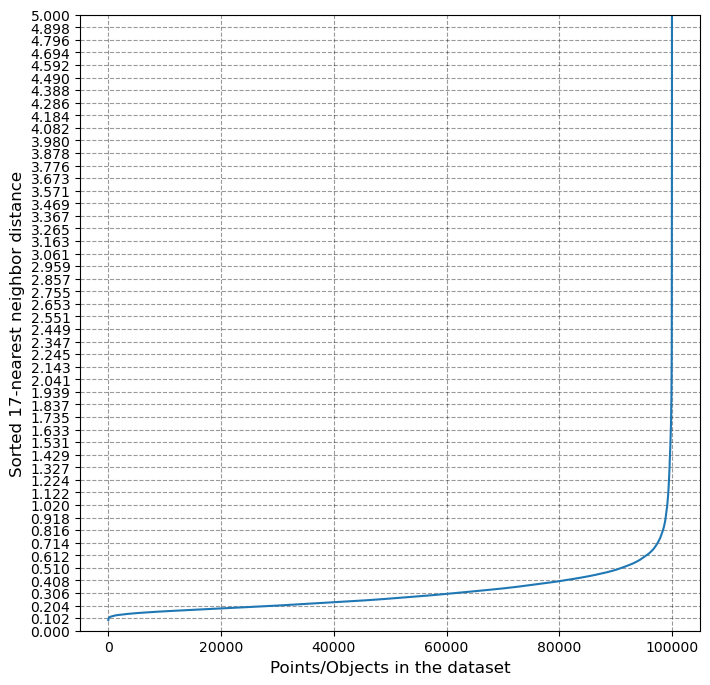

In [36]:
# To determine optimal eps hyperparameter for DBSCAN, take the y value at the elbow of the plot 

def get_kdist_plot(X=None, k=None, radius_nbrs=1.0):

    nbrs = NearestNeighbors(n_neighbors=k, radius=radius_nbrs).fit(X)

    # For each point, compute distances to its k-nearest neighbors
    distances, indices = nbrs.kneighbors(X) 
                                       
    distances = np.sort(distances, axis=0)
    distances = distances[:, k-1]

    # Plot the sorted K-nearest neighbor distance for each point in the dataset
    plt.figure(figsize=(8,8))
    plt.plot(distances)
    plt.xlabel('Points/Objects in the dataset', fontsize=12)
    plt.ylabel('Sorted {}-nearest neighbor distance'.format(k), fontsize=12)
    plt.grid(True, linestyle="--", color='black', alpha=0.4)
    plt.ylim(0, 5)
    y_tick_values = np.linspace(0, 5, 50)
    plt.yticks(y_tick_values) 
    plt.show()
    plt.close()


k = 2 * X_scaled.shape[-1] - 1 # k=2*{dim(dataset)} - 1
get_kdist_plot(X=X_scaled, k=k)

From the graph, eps = 0.65. For min_samples, a common approach is to use k = min_samples, which in this case is 17.

In [ ]:
# Apply DBSCAN clustering
# dbscan = DBSCAN(eps=0.65, min_samples=17)
# joblib.dump(dbscan, 'dbscan.pkl')

['dbscan.pkl']

In [127]:
loaded_dbscan = joblib.load('dbscan.pkl')
X_dbscan = loaded_dbscan.fit_predict(X_scaled)

In [108]:
pd.DataFrame(X_dbscan).value_counts()

0 
 0    98456
-1     1443
 1      101
Name: count, dtype: int64

#### Gaussian Mixture Models (GMM)

To determine the optimal number of clusters for GMM, I use Bayesian Information Criterion (BIC) and Akaike Information Criterion (AIC). These metrics balance the goodness of fit with the complexity of the model. 

I plot the AIC and BIC values obtained for different number of clusters when the GMM is fitted onto the data. The optimal number of clusters is at the "elbow" point of the curve, where the rate of decrease slows down. This balances model complexity with performance and avoids overfitting caused by an excessive number of components.

In [70]:
# Bayesian Information Criterion (BIC) and Akaike Information Criterion (AIC) to determine the best number of clusters for GMM
bics = []
aics = []
n_components_range = range(1, 10)  # Try different values for n_components

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components)
    gmm.fit(X_scaled)
    bics.append(gmm.bic(X_scaled))
    aics.append(gmm.aic(X_scaled))

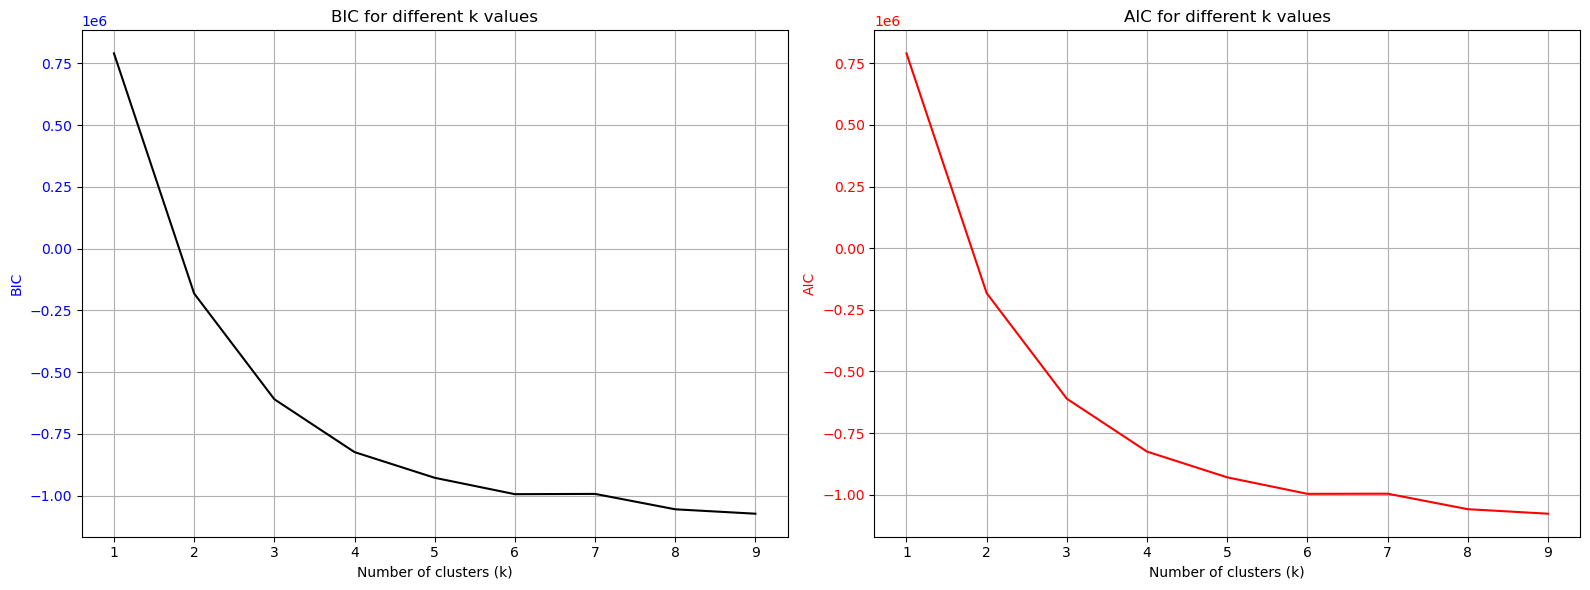

In [75]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# Plot BIC in the first subplot
ax1.plot(n_components_range, bics, label='BIC', color='black')
ax1.set_xlabel('Number of clusters (k)')
ax1.set_ylabel('BIC', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.set_title('BIC for different k values')
ax1.grid(True)

# Plot AIC in the second subplot
ax2.plot(n_components_range, aics, label='AIC', color='red')
ax2.set_xlabel('Number of clusters (k)')
ax2.set_ylabel('AIC', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_title('AIC for different k values')
ax2.grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

At the "elbow" point, the number of clusters = 3

In [ ]:
# Fit Gaussian Mixture Model
# gmm = GaussianMixture(n_components=3, random_state=42)
# joblib.dump(gmm, 'gmm.pkl')

['gmm.pkl']

In [115]:
loaded_gmm = joblib.load('gmm.pkl')
X_gmm = loaded_gmm.fit_predict(X_scaled)

#### Silhouette Score

The silhouette score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges between -1 and 1:

- 1: Indicates that clusters are well-separated, and points are appropriately assigned.
- 0: Suggests overlapping clusters or unclear boundaries.
- Negative values: Indicate that points are likely misclassified.

In [59]:
# K Means
silhouette_kmeans = silhouette_score(X_scaled, X_kmeans)
print(f'Silhouette Score for k-means: {silhouette_kmeans}')

Silhouette Score for k-means: 0.31673201535050866


In [111]:
# DBSCAN: need to filter out the points which are labelled -1 as noise 
mask = X_dbscan != -1
X_valid = X_scaled[mask]
dbscan_valid = X_dbscan[mask]
silhouette_dbscan = silhouette_score(X_valid, dbscan_valid)
print(f'Silhouette Score for DBSCAN: {silhouette_dbscan}')

Silhouette Score for DBSCAN: 0.026970864752672536


In [116]:
# GMM
silhouette_gmm = silhouette_score(X_scaled, X_gmm)
print(f'Silhouette Score for GMM: {silhouette_gmm}')

Silhouette Score for GMM: 0.17840708600190294


The silhouette scores do not show good clustering, with the highest being k-means with a value of 0.32. 

#### Cluster Distribution

In [118]:
# k-Means
unique_kmeans_clusters = len(set(X_kmeans))

# DBSCAN (note that DBSCAN labels noise points as -1)
unique_dbscan_clusters = len(set(X_dbscan) - {-1})

# GMM
unique_gmm_clusters = len(set(X_gmm))

print(f'Number of clusters in k-Means: {unique_kmeans_clusters}')
print(f'Number of clusters in DBSCAN: {unique_dbscan_clusters}')
print(f'Number of clusters in GMM: {unique_gmm_clusters}')

Number of clusters in k-Means: 3
Number of clusters in DBSCAN: 2
Number of clusters in GMM: 3


#### Visualising clustering results using dimensionality reduction

I will use a dimensionality reduction technique UMAP (Uniform Manifold Approximation and Projection) to visualise the clustering results in 2D, instead of PCA (Principal Component Analysis) as UMAP is able to better preserve non-linear relationships in the data.

In [112]:
umap_model = umap.UMAP(n_components = 2, random_state = 42)
X_umap = umap_model.fit_transform(X_scaled)

c:\Users\avell\anaconda3\envs\datasci\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


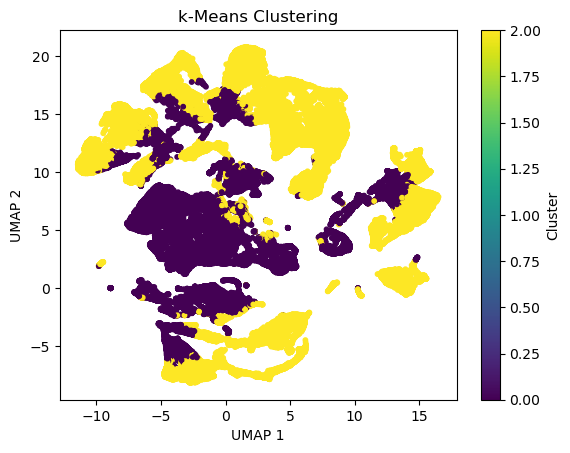

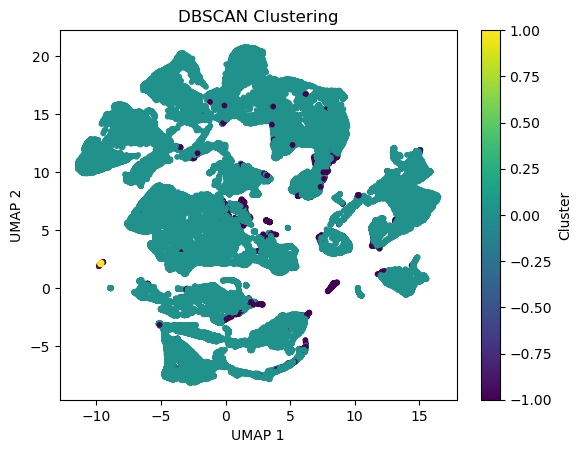

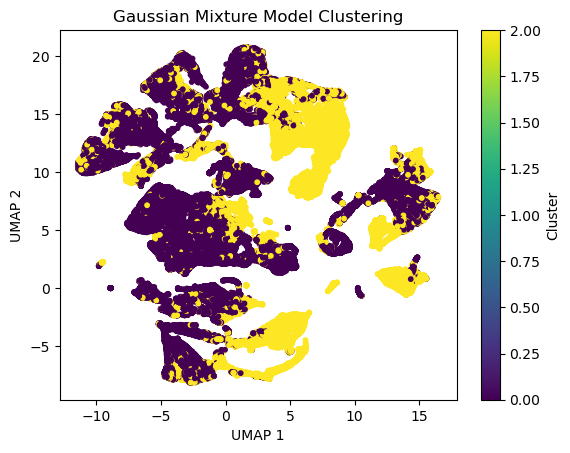

In [119]:
# Plot k-Means clusters
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=X_kmeans, cmap='viridis', s=10)
plt.title('k-Means Clustering')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(label='Cluster')
plt.show()

# Plot DBSCAN clusters
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=X_dbscan, cmap='viridis', s=10)
plt.title('DBSCAN Clustering')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(label='Cluster')
plt.show()

# Plot GMM clusters
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=X_gmm, cmap='viridis', s=10)
plt.title('Gaussian Mixture Model Clustering')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.colorbar(label='Cluster')
plt.show()

From the plots, the clusters are not clearly defined and are often overlapping. 

For k-means, it is likely that the clusters have non-spherical shapes, and also the number of clusters could have vastly different densities or sizes (our dataset has class imbalance among the 3 types of astronomical objects).

For DBSCAN, it may not perform well in high-dimensional spaces due to the curse of dimensionality. In our case, we have 9 feature dimensions, which may have led to poor clustering results. Clusters with different densities would also affect its performance. Further tuning of the hyperparameters eps and min_samples (perhaps using gridsearch) can also be explored, since DBSCAN is particularly sensitive to them. 

For GMM, it assumes that the data within each cluster follows a gaussian distribution. Hence, it may not have performed well if the true cluster shapes are highly irregular or non-Gaussian.

#### Adjusted Rand Index (ARI)
The ARI compares the clustering result to a ground truth class of each object, accounting for chance. A score closer to 1 indicates that the clustering is similar to the true labels, while a score closer to 0 indicates random clustering.

In [120]:
# y contains the label encodings of the true object classes (star, galaxy, quasar)
ari_kmeans = adjusted_rand_score(y, X_kmeans)
ari_dbscan = adjusted_rand_score(y, X_dbscan)
ari_gmm = adjusted_rand_score(y, X_gmm)

print(f'Adjusted Rand Index for k-Means: {ari_kmeans}')
print(f'Adjusted Rand Index for DBSCAN: {ari_dbscan}')
print(f'Adjusted Rand Index for GMM: {ari_gmm}')

Adjusted Rand Index for k-Means: 0.042777358947855317
Adjusted Rand Index for DBSCAN: 0.01881822293886353
Adjusted Rand Index for GMM: 0.23465455688995382


Clustering is mostly random, with the highest ARI score being only 0.235 for GMM

#### Discussion and Conclusion

Based on this analysis, the data is unable to be clustered well. More hyperparameter tuning is needed especially for DBSCAN to further investigate the performance of the models. Other algorithms like hierarchical clustering, spectral clustering, or t-SNE for dimensionality reduction with clustering can also be experimented.